#### 引入模組與定義公用函式  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

#### 更新量化技術分析資料庫  

In [3]:
mysys.UpdatestockDatabase()

2025-07-22 21:50:43.878 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockInfo, data_id: 


##### 更新台股總覽 #####
##### 更新技術分析資料 #####


2025-07-22 21:50:46.027 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:51:15.550 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:51:20.409 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:51:49.544 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:51:54.859 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:52:24.985 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:52:30.425 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:53:00.044 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-07-22 21:53:05.397 | INFO     | FinMind.data.finmind_api:get_data:155 - download Ta

日K：2025-07-22


#### 建立「解盤」物件    

In [4]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

解盤內容：


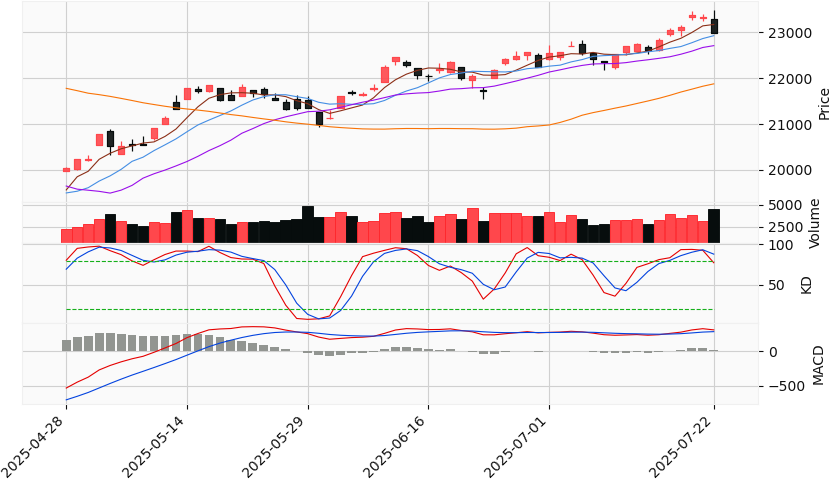

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-18 , 2025-07-21"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 4490.1億元 ，十日均量 ＝ 3470.8億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.25。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線上揚，長期盤整
ＫＤ指標,於2025-07-21死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-07-14該周在超買區。
整體評價,"根據圖表進行技術分析如下： 價格趨勢 目前價格呈現上漲趨勢。K線圖顯示價格持續高於短期（5日、10日）和中期（20日、60日）移動平均線，顯示出多頭趨勢。 價量關係 成交量在近期有增加的趨勢，尤其在價格上漲時伴隨著較高的成交量，顯示出多頭的強勢。 支撐與壓力 - 支撐位：短期支撐位可參考20日移動平均線，約在22,500點附近。 - 壓力位：目前價格接近23,000點，若能有效突破，將有機會挑戰更高的壓力位。 KD指標解讀 KD指標顯示K線（紅線）已經從超買區回落，並且與D線（藍線）形成死亡交叉，顯示短期可能有回檔壓力。 MACD指標解讀 MACD指標中，DIF線（紅線）高於MACD線（藍線），且灰色柱體（OSC）持續在正值區域，顯示中期仍維持多頭趨勢，但需注意柱體有縮短的跡象，可能預示動能減弱。 綜合評價 整體來看，市場目前仍處於多頭趨勢，但短期內可能面臨回檔壓力。建議投資者在短期內謹慎操作，考慮在支撐位附近尋找買入機會，並設置適當的停損點以控制風險。若價格能有效突破壓力位，則可考慮加碼持有。"


In [5]:
stock_analysis(analysis,'TAIEX')

現在只是回到楔形區間，但還沒跌破喔：  
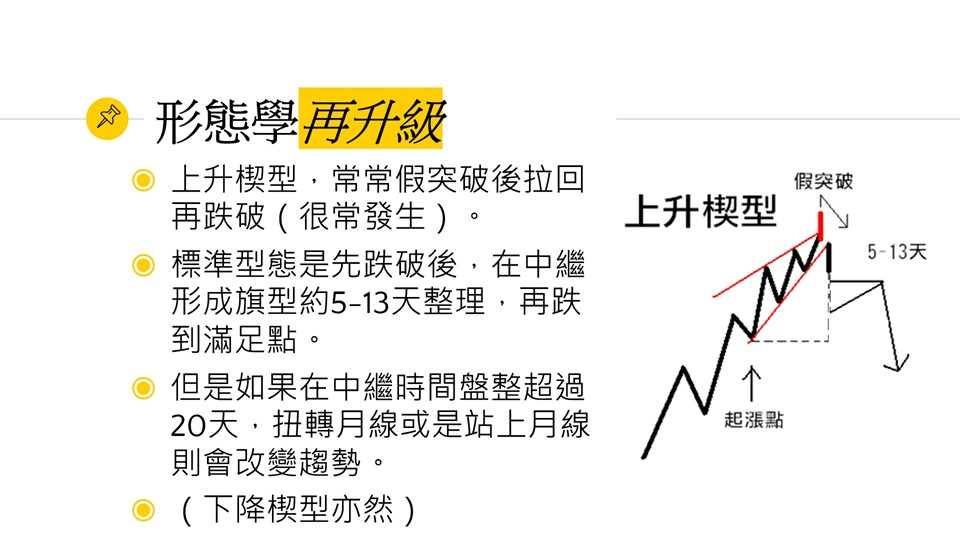  
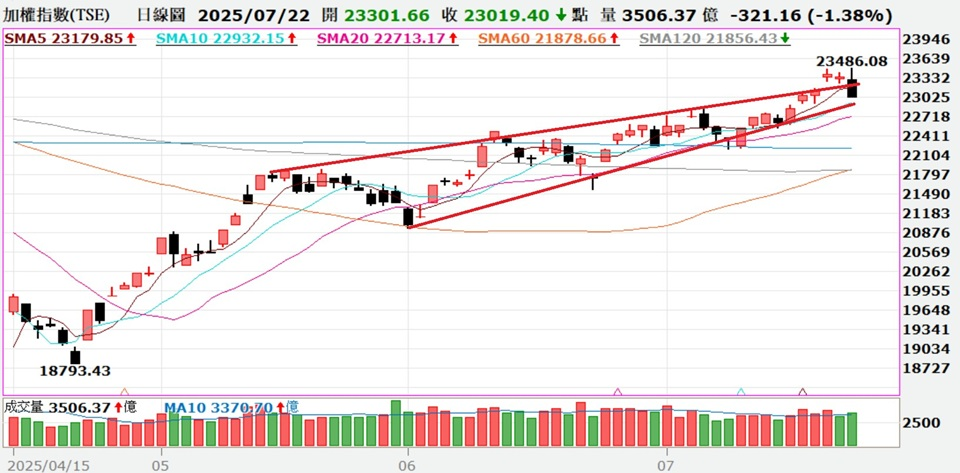  

In [6]:
def line_drawing_callback( range_prices) :

    seq_of_seq_of_points = []
    linewidths           = []
    colors               = []

    # 設定楔形壓力線
    resistance_line_start_date  = '2025-05-15'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.DateToIndex(range_prices,'2025-05-16'),mysys.DateToIndex(range_prices,'2025-07-17')]
    resistance_line_y           = [range_prices.loc['2025-05-16']['Close'],range_prices.loc['2025-07-17']['Close']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.DateToIndex(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line_end_date) + intercept
    seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)])
    linewidths.append(1.5)
    colors.append('xkcd:red')
    
    # 設定楔形支撐線
    support_line_start_date  = '2025-06-02'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.DateToIndex(range_prices,'2025-06-02'),mysys.DateToIndex(range_prices,'2025-07-15')]
    support_line_y           = [range_prices.loc['2025-06-02']['Low'],range_prices.loc['2025-07-15']['Open']]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.DateToIndex(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.DateToIndex(range_prices,support_line_end_date) + intercept
    seq_of_seq_of_points.append([(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)])
    linewidths.append(1.5)
    colors.append('xkcd:red')
    
    return seq_of_seq_of_points,linewidths,colors

In [7]:
image = mysys.DrawOnKlineChart('TAIEX','2025-04-15','2025-07-22',line_drawing_callback)

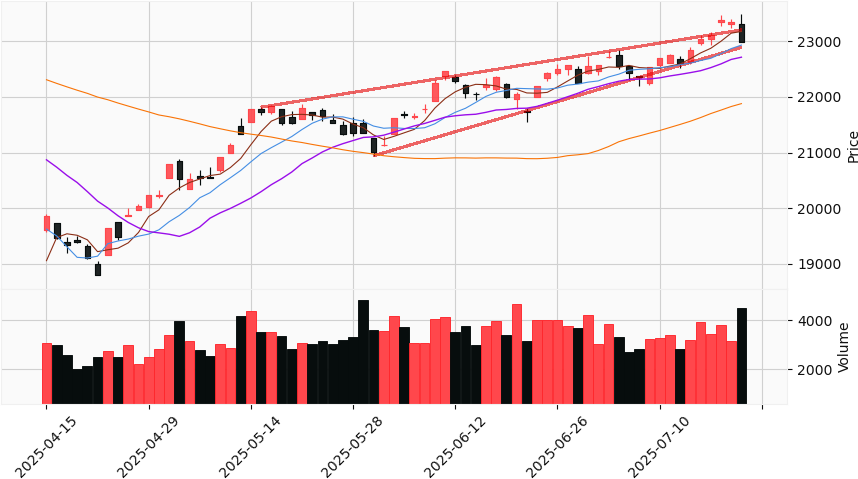

In [8]:
display(image)

* 櫃買指數  

解盤內容：


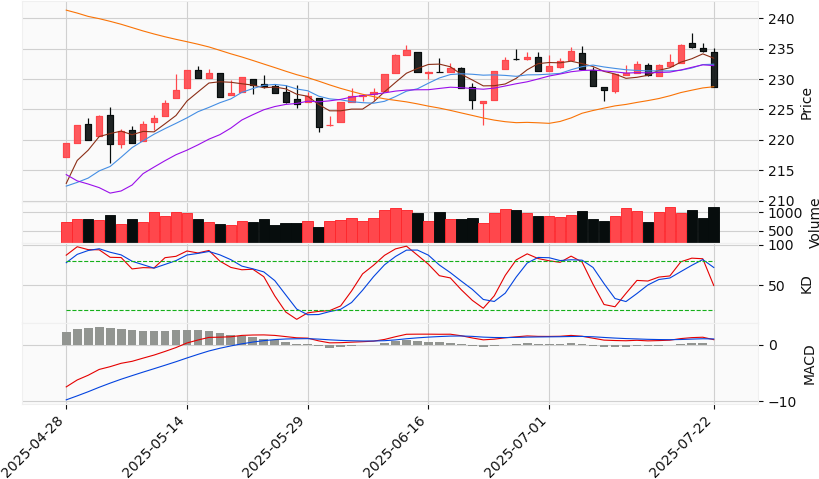

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"墓碑線 : 2025-07-21 , 2025-07-21 , 2025-07-21 , 2025-07-21 , 2025-07-21"
Ｋ線圖,中期為中位階 長期為低位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1132.76億元 ，十日均量 ＝ 998.5億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線下彎、10日線上揚，短期盤整；20日線下彎、60日線上揚，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-22死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢分析 近期價格呈現盤整走勢，K線在短期移動平均線（5日、10日）附近波動，並且多次測試中期移動平均線（20日、60日）。整體來看，價格在230至240點之間震盪。 價量關係 成交量在近期有明顯增加，尤其在價格上漲時伴隨著較高的成交量，顯示多頭動能較強。然而，最近一次的下跌也伴隨著較高的成交量，需注意空頭壓力。 支撐與壓力判斷 - 支撐位置：230點附近，該位置多次被測試且有支撐力道。 - 壓力位置：240點附近，價格多次在此遇阻。 KD指標解讀 KD指標顯示近期從超買區回落，K線已經跌破D線，顯示短期內可能有進一步回檔的風險。 MACD指標解讀 MACD指標中，DIF線與MACD線接近零軸，且柱狀體顯示動能減弱，短期內可能維持盤整或小幅回檔。 綜合評價 目前市場處於盤整階段，短期內可能會有回檔壓力。建議投資者謹慎操作，若價格跌破230點支撐，需考慮停損。若能有效突破240點壓力，則有望進一步上行。建議密切關注成交量變化及技術指標的進一步走勢。


In [9]:
stock_analysis(analysis,'TPEx')

### 個股解盤  

* 燿華(2367)  
  看法：底型突破，先看到前高。  

解盤內容：


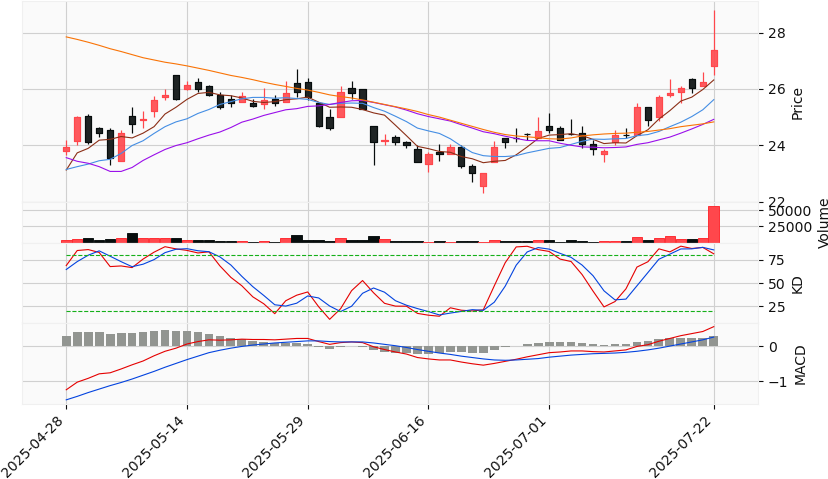

技術分析工具,解盤內容
Ｋ線／Ｋ棒,紡錘線 : 2025-07-16 十字線 : 2025-07-16
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：中小型股爆量／大型股天量（成交量 ＝ 56590張 ，十日均量 ＝ 10875張）
型態,盤整型態之三角形，型態範圍由2024-09-26開始到2025-01-09結束。 底型反轉之底部型態，型態範圍由2025-04-07開始到2025-04-29結束，估算目標價為28.19。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。並且2025-07-22於超買區。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-30當周黃金交叉。
整體評價,價格趨勢 近期股價呈現上漲趨勢，尤其在最後幾個交易日中，價格大幅上升，並突破了多條移動平均線。短期移動平均線（5日、10日）向上穿越中期移動平均線（20日、60日），顯示出強烈的多頭趨勢。 價量關係 成交量在最近幾個交易日顯著增加，尤其是最後一個交易日，成交量大幅放大，這與價格的上漲相互配合，顯示出市場的買盤力量強勁。 支撐與壓力判斷 目前股價已經突破前期高點，形成新的支撐位，約在26元附近。壓力位則可能在30元左右，需觀察後續價格能否持續突破。 KD指標解讀 KD指標顯示K線和D線均位於超買區域，且K線略微下彎，顯示出短期內可能有回檔壓力，需注意超買後的調整風險。 MACD指標解讀 MACD指標中，DIF線和MACD線均在零軸上方，且DIF線高於MACD線，顯示出多頭趨勢明顯。灰色柱體（OSC）持續增長，進一步確認了上漲動能。 綜合評價 綜合以上分析，目前市場呈現強烈的多頭趨勢，價格和成交量配合良好。然而，由於KD指標顯示超買，短期內可能會有回檔壓力。建議投資者在持有多單的同時，設置適當的停利和停損點，以應對可能的價格波動。若價格能夠穩定在支撐位之上，則中期上漲趨勢有望持續。


In [10]:
stock_analysis(analysis,'2367')

In [11]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-03-25'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-05-13']['Open']

    # 設定底部到頸線差距
    bottom_date  = '2025-06-23'
    bottom_price = range_prices.loc['2025-06-23']['Open']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)],
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [12]:
image = mysys.DrawOnKlineChart('2367','2024-12-30','2025-07-22',line_drawing_callback)

估算目標價為30.45元


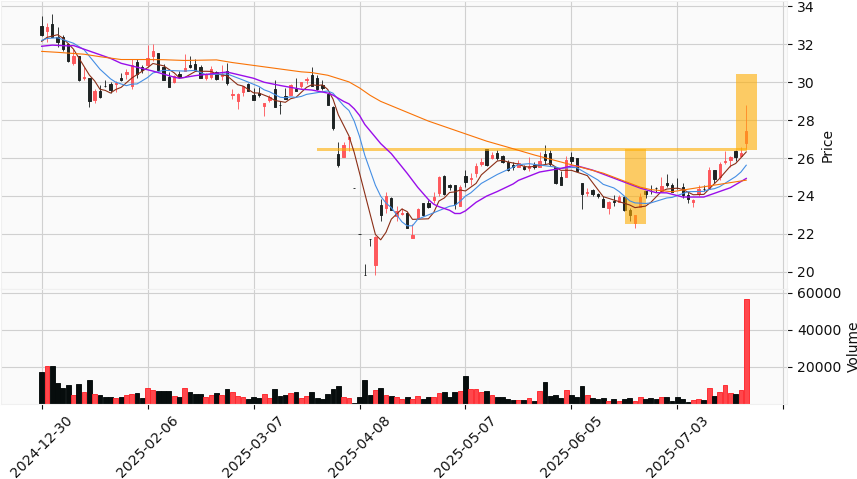

In [13]:
display(image)

籌碼面：  
法人大賣(-9564)：外資大賣(-9925)、投信中立(0)、自營小買(+361)。  
主力大賣(-6421)。  
分公司買賣家數差分散(-8)。  
融資大增(+3709)、融券增(+69)。  